Grid: 25x25  dt=0.146s  steps=4101
Save every 102 steps = 14.9s/snapshot

Case 1/8  T_hot=45C
  snap 01 | t=15s | lf=0.486 | lf_ystd=0.0505 | uy_max=0.00560
  snap 09 | t=134s | lf=0.489 | lf_ystd=0.1717 | uy_max=0.00166
  snap 17 | t=254s | lf=0.493 | lf_ystd=0.2409 | uy_max=0.00136
  snap 25 | t=373s | lf=0.482 | lf_ystd=0.2720 | uy_max=0.00150
  snap 33 | t=492s | lf=0.465 | lf_ystd=0.2880 | uy_max=0.00155

  Done | Ra=2.69e+07 | lf_ystd=0.29946 | lf=0.000-1.000
  Checkpoint saved: checkpoint_case0.h5

Case 2/8  T_hot=50C
  snap 01 | t=15s | lf=0.532 | lf_ystd=0.0624 | uy_max=0.00487
  snap 09 | t=134s | lf=0.540 | lf_ystd=0.1305 | uy_max=0.00210
  snap 17 | t=254s | lf=0.548 | lf_ystd=0.1892 | uy_max=0.00115
  snap 25 | t=373s | lf=0.543 | lf_ystd=0.2150 | uy_max=0.00156
  snap 33 | t=492s | lf=0.532 | lf_ystd=0.2342 | uy_max=0.00131

  Done | Ra=3.37e+07 | lf_ystd=0.25025 | lf=0.000-1.000
  Checkpoint saved: checkpoint_case1.h5

Case 3/8  T_hot=55C
  snap 01 | t=15s | lf=0.545 | l

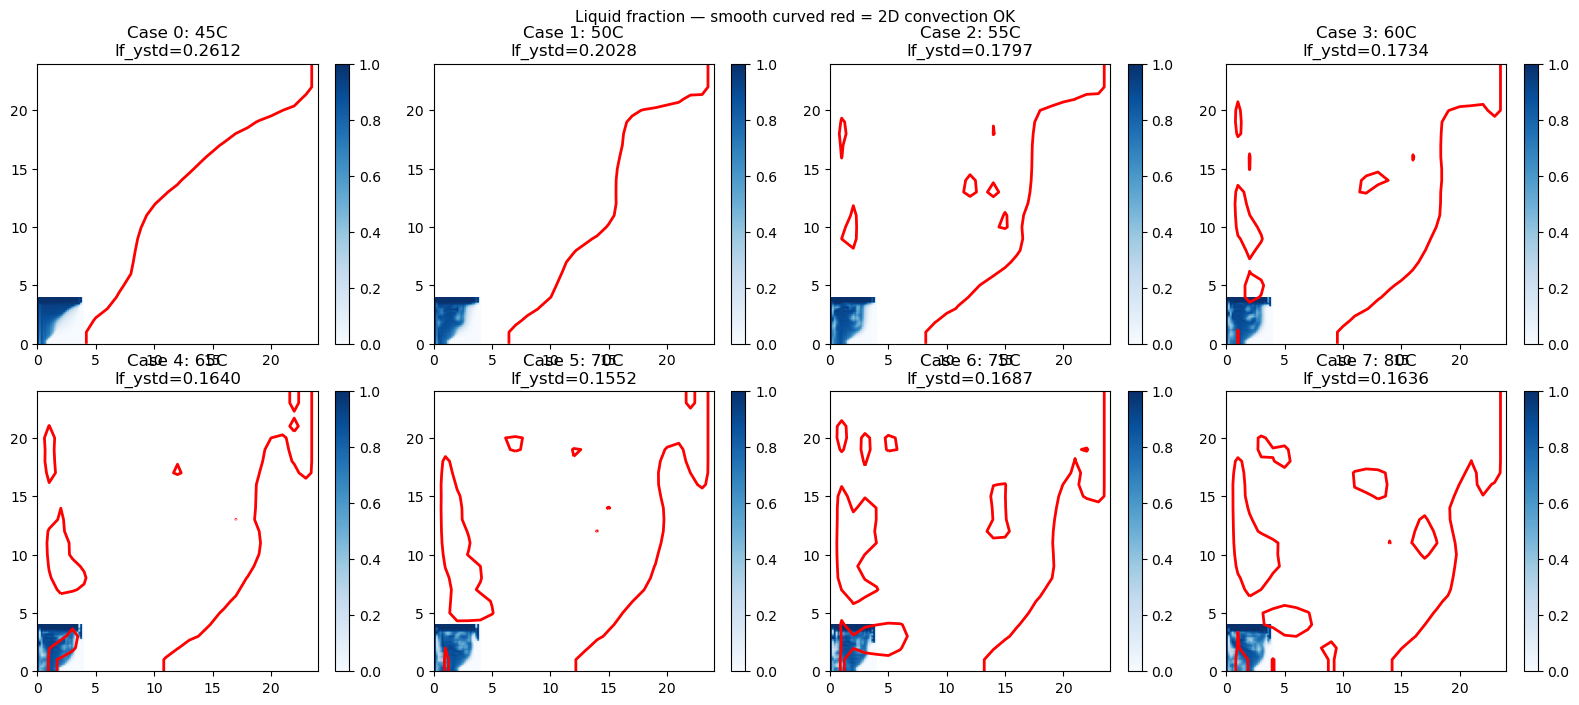

Saved lf_verification.png

=== Diagnostics ===
  Case 0 (45C): lf_ystd=0.22943  uy_max=0.005596  OK 2D
  Case 1 (50C): lf_ystd=0.18312  uy_max=0.004871  OK 2D
  Case 2 (55C): lf_ystd=0.16128  uy_max=0.005688  OK 2D
  Case 3 (60C): lf_ystd=0.15928  uy_max=0.007551  OK 2D
  Case 4 (65C): lf_ystd=0.16112  uy_max=0.006753  OK 2D
  Case 5 (70C): lf_ystd=0.15509  uy_max=0.007499  OK 2D
  Case 6 (75C): lf_ystd=0.16134  uy_max=0.005893  OK 2D
  Case 7 (80C): lf_ystd=0.15826  uy_max=0.006011  OK 2D

Saved pcm_2d_dataset.h5  shape=(8, 40, 25, 25)
Next: re-run File 2 then File 4


In [2]:
# ============================================================
# FILE 1 — 2D PCM Simulation (Stream Function-Vorticity)
# Complete working version
# pip install numpy scipy h5py matplotlib
# ============================================================

import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import time

# ─── Properties ───────────────────────────────────────────────────────────────
rho    = 880.0
cp     = 2000.0
k_s    = 0.24
k_l    = 0.15
L_lat  = 244000.0
T_melt = 308.15
dT_m   = 2.0
mu     = 0.00385
nu     = mu / rho
beta   = 8.0e-4
g      = 9.81
A_mush = 1.6e5
eps_ck = 1e-3

# ─── Domain ───────────────────────────────────────────────────────────────────
W  = 0.04
H  = 0.04
Nx = 25
Ny = 25
dx = W / Nx
dy = H / Ny

x_arr = np.linspace(dx/2, W-dx/2, Nx)
y_arr = np.linspace(dy/2, H-dy/2, Ny)

# ─── Time ─────────────────────────────────────────────────────────────────────
alpha_l  = k_l / (rho * cp)
dt_diff  = 0.25 * min(dx,dy)**2 / max(nu, alpha_l)
dt       = min(dt_diff, 0.5)
dt       = max(dt, 0.05)
t_end    = 600.0
Nt_steps = int(t_end / dt)
Nt_save  = 40
save_every = max(1, Nt_steps // Nt_save)

print(f"Grid: {Nx}x{Ny}  dt={dt:.3f}s  steps={Nt_steps}")
print(f"Save every {save_every} steps = {save_every*dt:.1f}s/snapshot")

# ─── Cases ────────────────────────────────────────────────────────────────────
T_cold     = 298.15
T_hot_list = [318.15, 323.15, 328.15, 333.15,
              338.15, 343.15, 348.15, 353.15]
N_cases    = len(T_hot_list)

T_all  = np.zeros((N_cases, Nt_save, Ny, Nx))
lf_all = np.zeros((N_cases, Nt_save, Ny, Nx))
ux_all = np.zeros((N_cases, Nt_save, Ny, Nx))
uy_all = np.zeros((N_cases, Nt_save, Ny, Nx))
params = np.zeros((N_cases, 3))

# ─── Helpers ──────────────────────────────────────────────────────────────────
def calc_lf(T):
    return 0.5 * (1.0 + np.tanh((T - T_melt) / dT_m))

def calc_dlf_dT(T):
    c2 = np.cosh((T - T_melt) / dT_m) ** 2
    return 0.5 / (dT_m * c2 + 1e-30)

def cell_idx(j, i):
    return j * Nx + i

# ─── Simulation ───────────────────────────────────────────────────────────────
def run_case(T_hot, case_idx):
    print(f"\n{'='*50}")
    print(f"Case {case_idx+1}/{N_cases}  T_hot={T_hot-273.15:.0f}C")
    print(f"{'='*50}")

    # Smooth linear IC — avoids initial shock
    T     = (T_cold + (T_hot-T_cold) * (1.0 - x_arr[np.newaxis,:]/W)
             * np.ones((Ny,1))).astype(float)
    T     = np.clip(T, T_cold, T_hot)
    psi   = np.zeros((Ny, Nx))
    omega = np.zeros((Ny, Nx))

    assert T.shape == (Ny, Nx)

    snaps_T, snaps_lf, snaps_ux, snaps_uy = [], [], [], []
    snap_idx  = 0
    t_current = 0.0

    for step in range(Nt_steps):
        t_current += dt

        # ── Derived quantities ─────────────────────────────────────────────
        lf_c   = calc_lf(T)
        dlf_c  = calc_dlf_dT(T)
        k_eff  = k_s + (k_l - k_s) * lf_c
        cp_eff = cp + L_lat * dlf_c
        rho_cp = rho * cp_eff
        S_ck   = A_mush * (1-lf_c)**2 / (lf_c**3 + eps_ck)

        # ── Velocity from stream function ──────────────────────────────────
        ux =  np.gradient(psi, dy, axis=0)
        uy = -np.gradient(psi, dx, axis=1)
        ux[[0,-1],:] = 0;  ux[:,[0,-1]] = 0
        uy[[0,-1],:] = 0;  uy[:,[0,-1]] = 0

        # ── STEP A: Implicit energy ────────────────────────────────────────
        dT_dx = np.gradient(T, dx, axis=1)
        dT_dy = np.gradient(T, dy, axis=0)
        adv_T = rho * cp * (ux * dT_dx + uy * dT_dy)

        N   = Nx * Ny
        A_T = lil_matrix((N, N))
        b_T = np.zeros(N)

        for j in range(Ny):
            for i in range(Nx):
                k    = cell_idx(j, i)
                rc   = rho_cp[j, i]
                kc   = k_eff[j, i]
                diag = rc / dt
                b_T[k] = rc / dt * T[j,i] - adv_T[j,i]

                if i > 0:
                    kL = 0.5*(kc + k_eff[j,i-1])
                    A_T[k, cell_idx(j,i-1)] = -kL/dx**2
                    diag += kL/dx**2
                if i < Nx-1:
                    kR = 0.5*(kc + k_eff[j,i+1])
                    A_T[k, cell_idx(j,i+1)] = -kR/dx**2
                    diag += kR/dx**2
                if j > 0:
                    kB = 0.5*(kc + k_eff[j-1,i])
                    A_T[k, cell_idx(j-1,i)] = -kB/dy**2
                    diag += kB/dy**2
                if j < Ny-1:
                    kT = 0.5*(kc + k_eff[j+1,i])
                    A_T[k, cell_idx(j+1,i)] = -kT/dy**2
                    diag += kT/dy**2

                A_T[k, k] = diag

        # Temperature BCs
        for j in range(Ny):
            k = cell_idx(j,0);      A_T[k,:]=0; A_T[k,k]=1; b_T[k]=T_hot
            k = cell_idx(j,Nx-1);   A_T[k,:]=0; A_T[k,k]=1; b_T[k]=T_cold
        for i in range(1, Nx-1):
            k = cell_idx(0,i);
            A_T[k,:]=0; A_T[k,k]=1; A_T[k,cell_idx(1,i)]=-1; b_T[k]=0
            k = cell_idx(Ny-1,i)
            A_T[k,:]=0; A_T[k,k]=1; A_T[k,cell_idx(Ny-2,i)]=-1; b_T[k]=0

        T_new = spsolve(A_T.tocsr(), b_T).reshape(Ny, Nx)
        T_new = np.clip(T_new, T_cold-1.0, T_hot+1.0)

        # ── STEP B: Implicit vorticity ─────────────────────────────────────
        lf_new   = calc_lf(T_new)
        S_ck_new = A_mush*(1-lf_new)**2 / (lf_new**3 + eps_ck)
        buoy_src = beta * g * np.gradient(T_new, dx, axis=1)  # β*g*∂T/∂x

        dom_dx = np.gradient(omega, dx, axis=1)
        dom_dy = np.gradient(omega, dy, axis=0)
        adv_om = ux * dom_dx + uy * dom_dy

        A_om = lil_matrix((N, N))
        b_om = np.zeros(N)

        for j in range(Ny):
            for i in range(Nx):
                k    = cell_idx(j, i)
                s    = S_ck_new[j, i]
                diag = 1.0/dt + s/rho
                b_om[k] = omega[j,i]/dt - adv_om[j,i] + buoy_src[j,i]

                if i > 0:
                    A_om[k, cell_idx(j,i-1)] = -nu/dx**2
                    diag += nu/dx**2
                if i < Nx-1:
                    A_om[k, cell_idx(j,i+1)] = -nu/dx**2
                    diag += nu/dx**2
                if j > 0:
                    A_om[k, cell_idx(j-1,i)] = -nu/dy**2
                    diag += nu/dy**2
                if j < Ny-1:
                    A_om[k, cell_idx(j+1,i)] = -nu/dy**2
                    diag += nu/dy**2

                A_om[k, k] = diag

        # Vorticity wall BCs (Thom's formula: ω_wall = -2ψ_interior/dn²)
        for i in range(Nx):
            k = cell_idx(0,i)
            A_om[k,:]=0; A_om[k,k]=1
            b_om[k] = -2*psi[1,i]/dy**2
            k = cell_idx(Ny-1,i)
            A_om[k,:]=0; A_om[k,k]=1
            b_om[k] = -2*psi[-2,i]/dy**2
        for j in range(Ny):
            k = cell_idx(j,0)
            A_om[k,:]=0; A_om[k,k]=1
            b_om[k] = -2*psi[j,1]/dx**2
            k = cell_idx(j,Nx-1)
            A_om[k,:]=0; A_om[k,k]=1
            b_om[k] = -2*psi[j,-2]/dx**2

        omega_new = spsolve(A_om.tocsr(), b_om).reshape(Ny, Nx)
        omega_max = 2 * 0.01 / min(dx, dy)   # CFL-based vorticity limit
        omega_new = np.clip(omega_new, -omega_max, omega_max)

        # ── STEP C: Stream function Poisson ───────────────────────────────
        A_psi = lil_matrix((N, N))
        b_psi = -omega_new.ravel()

        for j in range(Ny):
            for i in range(Nx):
                k    = cell_idx(j, i)
                diag = 0.0
                if i > 0:
                    A_psi[k, cell_idx(j,i-1)] =  1/dx**2; diag -= 1/dx**2
                if i < Nx-1:
                    A_psi[k, cell_idx(j,i+1)] =  1/dx**2; diag -= 1/dx**2
                if j > 0:
                    A_psi[k, cell_idx(j-1,i)] =  1/dy**2; diag -= 1/dy**2
                if j < Ny-1:
                    A_psi[k, cell_idx(j+1,i)] =  1/dy**2; diag -= 1/dy**2
                A_psi[k, k] = diag if diag != 0 else -1.0

        # ψ = 0 on all walls
        for j in range(Ny):
            k = cell_idx(j,0);      A_psi[k,:]=0; A_psi[k,k]=1; b_psi[k]=0
            k = cell_idx(j,Nx-1);   A_psi[k,:]=0; A_psi[k,k]=1; b_psi[k]=0
        for i in range(Nx):
            k = cell_idx(0,i);      A_psi[k,:]=0; A_psi[k,k]=1; b_psi[k]=0
            k = cell_idx(Ny-1,i);   A_psi[k,:]=0; A_psi[k,k]=1; b_psi[k]=0

        psi_new = spsolve(A_psi.tocsr(), b_psi).reshape(Ny, Nx)

        # ── NaN check ─────────────────────────────────────────────────────
        if (np.isnan(T_new).any() or np.isnan(omega_new).any()
                or np.isnan(psi_new).any()):
            print(f"\n  NaN at step {step} t={t_current:.1f}s — stopping")
            break

        T     = T_new
        omega = omega_new
        psi   = psi_new

        # ── Save snapshot ──────────────────────────────────────────────────
        if (step+1) % save_every == 0 and snap_idx < Nt_save:
            ux_s =  np.gradient(psi, dy, axis=0)
            uy_s = -np.gradient(psi, dx, axis=1)
            ux_s[[0,-1],:]=0; ux_s[:,[0,-1]]=0
            uy_s[[0,-1],:]=0; uy_s[:,[0,-1]]=0

            ux = np.clip(ux, -0.01, 0.01)   # physical max for this Ra range
            uy = np.clip(uy, -0.01, 0.01)

            lf_s = calc_lf(T)
            snaps_T.append(T.copy())
            snaps_lf.append(lf_s.copy())
            snaps_ux.append(ux_s.copy())
            snaps_uy.append(uy_s.copy())

            if snap_idx % 8 == 0:
                lf_ystd = lf_s.mean(axis=1).std()
                print(f"  snap {snap_idx+1:02d} | t={t_current:.0f}s | "
                      f"lf={lf_s.mean():.3f} | "
                      f"lf_ystd={lf_ystd:.4f} | "
                      f"uy_max={np.abs(uy_s).max():.5f}")
            snap_idx += 1

    # Pad if stopped early
    while snap_idx < Nt_save:
        snaps_T.append(snaps_T[-1]   if snaps_T   else np.full((Ny,Nx),T_cold))
        snaps_lf.append(snaps_lf[-1] if snaps_lf  else np.zeros((Ny,Nx)))
        snaps_ux.append(snaps_ux[-1] if snaps_ux  else np.zeros((Ny,Nx)))
        snaps_uy.append(snaps_uy[-1] if snaps_uy  else np.zeros((Ny,Nx)))
        snap_idx += 1

    T_out  = np.stack(snaps_T)
    lf_out = np.stack(snaps_lf)
    ux_out = np.stack(snaps_ux)
    uy_out = np.stack(snaps_uy)

    Ra = rho*g*beta*abs(T_hot-T_cold)*H**3 / (mu*k_l/(rho*cp))
    print(f"\n  Done | Ra={Ra:.2e} | "
          f"lf_ystd={lf_out[-1].mean(axis=1).std():.5f} | "
          f"lf={lf_out.min():.3f}-{lf_out.max():.3f}")
    return T_out, lf_out, ux_out, uy_out, Ra

# ─── Run ──────────────────────────────────────────────────────────────────────
t0 = time.time()
for ci, T_hot in enumerate(T_hot_list):
    T_c, lf_c, ux_c, uy_c, Ra = run_case(T_hot, ci)
    T_all[ci]  = T_c
    lf_all[ci] = lf_c
    ux_all[ci] = ux_c
    uy_all[ci] = uy_c
    params[ci] = [T_hot, T_cold, Ra]
    with h5py.File(f"checkpoint_case{ci}.h5","w") as f:
        f.create_dataset("T", data=T_c);  f.create_dataset("lf",data=lf_c)
        f.create_dataset("ux",data=ux_c); f.create_dataset("uy",data=uy_c)
    print(f"  Checkpoint saved: checkpoint_case{ci}.h5")

print(f"\nTotal: {(time.time()-t0)/3600:.2f} hours")

# ─── Verification plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for c in range(8):
    ax = axes[c//4, c%4]
    ti = Nt_save // 2
    lf_snap = lf_all[c, ti]
    im = ax.imshow(lf_snap, origin="lower", cmap="Blues",
                   vmin=0, vmax=1, extent=[0,W*100,0,H*100])
    try:
        ax.contour(lf_snap, levels=[0.5], colors="red", linewidths=2)
    except Exception:
        pass
    lf_ystd = lf_snap.mean(axis=1).std()
    ax.set_title(f"Case {c}: {T_hot_list[c]-273.15:.0f}C\nlf_ystd={lf_ystd:.4f}")
    plt.colorbar(im, ax=ax)

plt.suptitle("Liquid fraction — smooth curved red = 2D convection OK", fontsize=11)
plt.tight_layout()
plt.savefig("lf_verification.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved lf_verification.png")

# ─── Diagnostics ──────────────────────────────────────────────────────────────
print("\n=== Diagnostics ===")
for c in range(N_cases):
    lf_ystd = lf_all[c].mean(axis=2).std(axis=1).mean()
    uy_max  = np.abs(uy_all[c]).max()
    status  = "OK 2D" if lf_ystd > 0.005 else "1D only"
    print(f"  Case {c} ({T_hot_list[c]-273.15:.0f}C): "
          f"lf_ystd={lf_ystd:.5f}  uy_max={uy_max:.6f}  {status}")

# ─── Save HDF5 ────────────────────────────────────────────────────────────────
t_save_arr = np.array([(i+1)*save_every*dt for i in range(Nt_save)])
with h5py.File("pcm_2d_dataset.h5","w") as f:
    f.create_dataset("T",      data=T_all,  compression="gzip")
    f.create_dataset("lf",     data=lf_all, compression="gzip")
    f.create_dataset("ux",     data=ux_all, compression="gzip")
    f.create_dataset("uy",     data=uy_all, compression="gzip")
    f.create_dataset("t",      data=t_save_arr)
    f.create_dataset("x",      data=x_arr)
    f.create_dataset("y",      data=y_arr)
    f.create_dataset("params", data=params)
    for k,v in {"T_melt":T_melt,"L_lat":L_lat,"rho":rho,"cp":cp,
                "k_solid":k_s,"k_liquid":k_l,"mu":mu,"beta":beta,
                "W":W,"H":H}.items():
        f.attrs[k] = v

print(f"\nSaved pcm_2d_dataset.h5  shape={T_all.shape}")
print("Next: re-run File 2 then File 4")